In [52]:
import StableDiffusion.ModelConverter
from StableDiffusion.DiffusionProcess import DiffusionProcess
device = 'cuda'
idleDevice = 'cpu'
filePath='../models/sd15models/v1-5-pruned-emaonly.ckpt'
diffusionDict = StableDiffusion.ModelConverter.load_from_standard_weights(input_file=filePath,\
                                                            device = 'cuda')
vaeEncoderWeights = diffusionDict['encoder']
vaeDecoderWeights = diffusionDict['decoder']


import torch 
import StableDiffusion.VaeEncoder 
import StableDiffusion.VaeDecoder
import StableDiffusion.ClipEncoder
import StableDiffusion.DiffusionProcess
import importlib
importlib.reload(StableDiffusion.VaeEncoder)
importlib.reload(StableDiffusion.VaeDecoder)
importlib.reload(StableDiffusion.ClipEncoder)
importlib.reload(StableDiffusion.DiffusionProcess)
from StableDiffusion.VaeDecoder import VaeDecoder
from StableDiffusion.VaeEncoder import VaeEncoder
from StableDiffusion.ClipEncoder import ClipEncoder
from StableDiffusion.DiffusionProcess import DiffusionProcess
vaeEncoder = VaeEncoder().to(device)
vaeDecoder = VaeDecoder().to(device)
vaeEncoder.load_state_dict(vaeEncoderWeights ,strict=True)
vaeDecoder.load_state_dict(vaeDecoderWeights,strict=True)


<All keys matched successfully>

In [45]:

import torch
from torch.utils.data import Dataset, DataLoader
import StableDiffusion.Dit.DitConfig
import StableDiffusion.Dit.DitMlp
import StableDiffusion.Dit.DitPatchEmbedding
import StableDiffusion.Dit.DitAttention
import StableDiffusion.Dit.DitEncoderLayer
import StableDiffusion.Dit.DitEncoder
import StableDiffusion.Dit.DitTower
import StableDiffusion.Dit.DitUnPatchEmbedding
import StableDiffusion.Dit.DitPositionEmbedding
import StableDiffusion.Dit.DitTimeEmbedding
import StableDiffusion.Dit.DitClassEmbedding
import StableDiffusion.Dit.DitDataSet


import importlib
modules =[
    StableDiffusion.Dit.DitConfig,
    StableDiffusion.Dit.DitPatchEmbedding,
    StableDiffusion.Dit.DitMlp,
    StableDiffusion.Dit.DitAttention,  
    StableDiffusion.Dit.DitEncoderLayer,
    StableDiffusion.Dit.DitEncoder,
    StableDiffusion.Dit.DitTower,
    StableDiffusion.Dit.DitUnPatchEmbedding,
    StableDiffusion.Dit.DitPositionEmbedding,
    StableDiffusion.Dit.DitTimeEmbedding,
    StableDiffusion.Dit.DitClassEmbedding,
    StableDiffusion.Dit.DitDataSet,
]
for module in modules:
    importlib.reload(module)


from StableDiffusion.Dit.DitConfig import DitConfig
from StableDiffusion.Dit.DitMlp import DitMlp
from StableDiffusion.Dit.DitPatchEmbedding import DitPatchEmbedding
from StableDiffusion.Dit.DitAttention import DitAttention
from StableDiffusion.Dit.DitEncoderLayer import DitEncoderLayer
from StableDiffusion.Dit.DitEncoder import DitEncoder
from StableDiffusion.Dit.DitTower import DitTower
from StableDiffusion.Dit.DitUnPatchEmbedding import DitUnPatchEmbedding
from StableDiffusion.Dit.DitPositionEmbedding import DitPositionEmbedding
from StableDiffusion.Dit.DitTimeEmbedding import DitTimeEmbedding
from StableDiffusion.Dit.DitClassEmbedding import DitClassEmbedding
from StableDiffusion.Dit.DitDataSet import DitDataSet
device = 'cuda'


ditConfig = DitConfig()
ClassNum = ditConfig.classNum 
classIdBatch = torch.randint(0,ClassNum + 1,(5,)).to(device)
print(f'classidbatch {classIdBatch}, classidbatch.shape {classIdBatch.shape}')
ditClassEmbedding = DitClassEmbedding(ditConfig).to(device)
classEmbedding = ditClassEmbedding(classIdBatch)
print(classEmbedding.shape)


timeSteps = torch.randint(0,1000,(5,)).to(device)
print(f'timeSteps {timeSteps},timeSteps.shape {timeSteps.shape} ')
imgBatch = torch.randn(5, 4,64,64).to(device)
ditTower =DitTower(ditConfig).to(device)
inputLatent = ditTower(imgBatch,classIdBatch,timeSteps)
print(f'dit tower:{inputLatent.shape}')



timeSteps = torch.randint(0,1000,(5,)).to(device)
print(f'timeSteps {timeSteps},timeSteps.shape {timeSteps.shape} ')
ditTimeEmbedding = DitTimeEmbedding(ditConfig).to(device)
timeEmbedding = ditTimeEmbedding(timeSteps)
print(timeEmbedding.shape)




classidbatch tensor([0, 1, 1, 1, 0], device='cuda:0'), classidbatch.shape torch.Size([5])
torch.Size([5, 1152])
timeSteps tensor([372, 236, 463, 601, 585], device='cuda:0'),timeSteps.shape torch.Size([5]) 
dit tower:torch.Size([5, 4, 64, 64])
timeSteps tensor([894, 163,  71,  63, 458], device='cuda:0'),timeSteps.shape torch.Size([5]) 
torch.Size([5, 1152])


torch.Size([3, 512, 512])


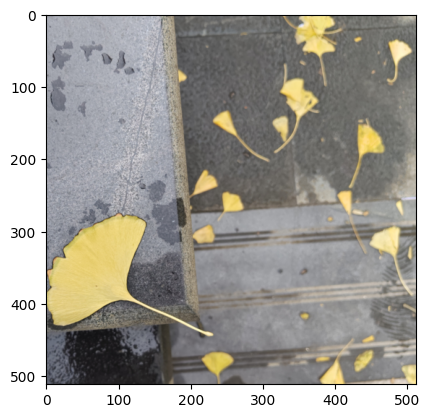

prompt:tensor([0], device='cuda:0') nonprompt:tensor([1], device='cuda:0')


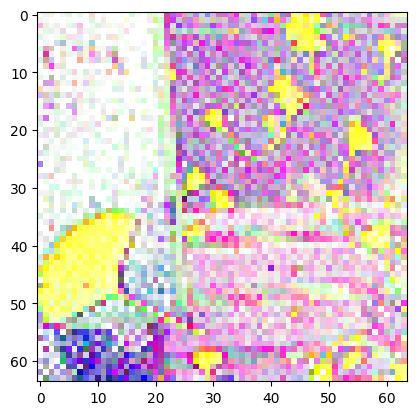

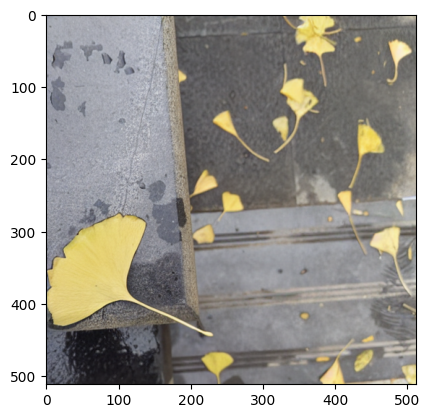

torch.Size([1, 4, 64, 64])


In [56]:
from torch.utils.data import Dataset, DataLoader
from StableDiffusion.Utils import *
ditDataSet = DitDataSet()
imageBatch = ditDataSet[100]
print(imageBatch.shape)
Utils.showBatchImage(imageBatch[None,...])
ditDataLoader  = DataLoader(ditDataSet,batch_size=5,
                                shuffle=True,num_workers=0,drop_last=True,collate_fn=None)
ditConfig = DitConfig()
ClassNum = ditConfig.classNum 
prompt = torch.tensor([ClassNum - 1], dtype=torch.long, device=device)
nonprompt = torch.tensor([ClassNum], dtype=torch.long, device=device)
timeSteps = torch.tensor([100], dtype=torch.long, device=device)
print(f'prompt:{prompt} nonprompt:{nonprompt}')
latentImg = vaeEncoder(imageBatch[None,...])
Utils.showBatchImage(latentImg)
recoverImg = vaeDecoder(latentImg)
Utils.showBatchImage(recoverImg)

hiddenStates = ditTower(latentImg,prompt,timeSteps)
print(hiddenStates.shape)



In [9]:
ditConfig = DitConfig()
ClassNum = ditConfig.classNum 
classIdBatch = torch.randint(0,ClassNum + 1,(10,)).to(device)
B, = classIdBatch.shape
mask = torch.rand(B).to(device)
print(mask.shape)
mask = mask > 0.3
classIdBatch = torch.where(mask,classIdBatch,ClassNum)
print(classIdBatch)

torch.Size([10])
tensor([0, 0, 0, 1, 1, 1, 1, 0, 1, 1], device='cuda:0')


In [1]:
for name,param in ditTower.named_parameters():
    print(name,param.shape)

NameError: name 'ditTower' is not defined

In [10]:
p = torch.arange(0,10)
print(p.shape)
print(p.size)
p = p[None,:]
print(p.shape)
ditPositionEmbedding = DitPositionEmbedding(ditConfig)
positionBatch = ditPositionEmbedding.get1DPositionEncoding(torch.arange(0,10),1152)
positionBatch2D = ditPositionEmbedding.get2DPositionEncoding( 1152)
print(positionBatch.shape)
print(positionBatch2D.shape)

torch.Size([10])
<built-in method size of Tensor object at 0x7f1c70d0d7b0>
torch.Size([1, 10])
torch.Size([10, 1152])
torch.Size([64, 1152])


In [20]:
gridSize =  4
gridH = torch.arange(gridSize,dtype = torch.float32)
gridW = torch.arange(gridSize,dtype = torch.float32)
grid = torch.meshgrid(gridW,gridH,indexing='xy')
print(grid)
grid = torch.stack(grid,dim=0)
print(grid.shape)
grid = grid[:,None,:,:]
print(grid.shape)
grid0 = grid[0]
print(grid0.shape)
list0 = grid0.reshape(-1)
print(list0.shape)



(tensor([[0., 1., 2., 3.],
        [0., 1., 2., 3.],
        [0., 1., 2., 3.],
        [0., 1., 2., 3.]]), tensor([[0., 0., 0., 0.],
        [1., 1., 1., 1.],
        [2., 2., 2., 2.],
        [3., 3., 3., 3.]]))
torch.Size([2, 4, 4])
torch.Size([2, 1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([16])


In [10]:
import numpy as np
grid_size=10
grid_h = np.arange(grid_size, dtype=np.float32)
grid_w = np.arange(grid_size, dtype=np.float32)
grid = np.meshgrid(grid_w, grid_h)  # here w goes first
print(grid)
grid = np.stack(grid, axis=0)
print(grid)
print(grid.shape)


grid = grid.reshape([2, 1, grid_size, grid_size])

(array([[0., 1., 2., 3., 4., 5., 6., 7., 8., 9.],
       [0., 1., 2., 3., 4., 5., 6., 7., 8., 9.],
       [0., 1., 2., 3., 4., 5., 6., 7., 8., 9.],
       [0., 1., 2., 3., 4., 5., 6., 7., 8., 9.],
       [0., 1., 2., 3., 4., 5., 6., 7., 8., 9.],
       [0., 1., 2., 3., 4., 5., 6., 7., 8., 9.],
       [0., 1., 2., 3., 4., 5., 6., 7., 8., 9.],
       [0., 1., 2., 3., 4., 5., 6., 7., 8., 9.],
       [0., 1., 2., 3., 4., 5., 6., 7., 8., 9.],
       [0., 1., 2., 3., 4., 5., 6., 7., 8., 9.]], dtype=float32), array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [2., 2., 2., 2., 2., 2., 2., 2., 2., 2.],
       [3., 3., 3., 3., 3., 3., 3., 3., 3., 3.],
       [4., 4., 4., 4., 4., 4., 4., 4., 4., 4.],
       [5., 5., 5., 5., 5., 5., 5., 5., 5., 5.],
       [6., 6., 6., 6., 6., 6., 6., 6., 6., 6.],
       [7., 7., 7., 7., 7., 7., 7., 7., 7., 7.],
       [8., 8., 8., 8., 8., 8., 8., 8., 8., 8.],
       [9., 9., 9., 9., 9., 9., 9., 9., 9., 9.]], d

In [6]:
a = torch.arange(0,10)
print(a.shape)

torch.Size([10])


torch.Size([10])
<built-in method size of Tensor object at 0x7f7dc0241ee0>
torch.Size([1, 10])
torch.Size([10, 1152])


In [5]:
for name,param in ditTower.named_parameters():
    print(name,param.shape,param.device)

vision_model.encoder.layers.0.self_attn.k_proj.weight torch.Size([1152, 1152]) cuda:0
vision_model.encoder.layers.0.self_attn.k_proj.bias torch.Size([1152]) cuda:0
vision_model.encoder.layers.0.self_attn.v_proj.weight torch.Size([1152, 1152]) cuda:0
vision_model.encoder.layers.0.self_attn.v_proj.bias torch.Size([1152]) cuda:0
vision_model.encoder.layers.0.self_attn.q_proj.weight torch.Size([1152, 1152]) cuda:0
vision_model.encoder.layers.0.self_attn.q_proj.bias torch.Size([1152]) cuda:0
vision_model.encoder.layers.0.self_attn.out_proj.weight torch.Size([1152, 1152]) cuda:0
vision_model.encoder.layers.0.self_attn.out_proj.bias torch.Size([1152]) cuda:0
vision_model.encoder.layers.0.layer_norm1.weight torch.Size([1152]) cuda:0
vision_model.encoder.layers.0.layer_norm1.bias torch.Size([1152]) cuda:0
vision_model.encoder.layers.0.layer_norm2.weight torch.Size([1152]) cuda:0
vision_model.encoder.layers.0.layer_norm2.bias torch.Size([1152]) cuda:0
vision_model.encoder.layers.0.mlp.fc1.weight

In [4]:
import torch
import StableDiffusion.Dit.DitConfig
import StableDiffusion.Dit.DitMlp
import StableDiffusion.Dit.DitPatchEmbedding
import StableDiffusion.Dit.DitAttention
import StableDiffusion.Dit.DitEncoderLayer
import StableDiffusion.Dit.DitEncoder
import StableDiffusion.Dit.DitTower
import StableDiffusion.Dit.DitUnPatchEmbedding


import importlib
modules =[
    StableDiffusion.Dit.DitConfig,
    StableDiffusion.Dit.DitPatchEmbedding,
    StableDiffusion.Dit.DitMlp,
    StableDiffusion.Dit.DitAttention,  
    StableDiffusion.Dit.DitEncoderLayer,
    StableDiffusion.Dit.DitEncoder,
    StableDiffusion.Dit.DitTower,
    StableDiffusion.Dit.DitUnPatchEmbedding,
]
for module in modules:
    importlib.reload(module)

from StableDiffusion.Dit.DitConfig import DitConfig
from StableDiffusion.Dit.DitMlp import DitMlp
from StableDiffusion.Dit.DitPatchEmbedding import DitPatchEmbedding
from StableDiffusion.Dit.DitAttention import DitAttention
from StableDiffusion.Dit.DitEncoderLayer import DitEncoderLayer
from StableDiffusion.Dit.DitEncoder import DitEncoder
from StableDiffusion.Dit.DitTower import DitTower
from StableDiffusion.Dit.DitUnPatchEmbedding import DitUnPatchEmbedding


ditConfig = DitConfig()
ditMlp  = DitMlp(ditConfig)
ditPatchEmbedding = DitPatchEmbedding(ditConfig)
latentInput = torch.randn(5, 4,64,64)
latentInput = ditPatchEmbedding(latentInput)
print(latentInput.shape)
latentInput = torch.randn(5, 256,1152)
latentInput = ditMlp(latentInput)
print(latentInput.shape)


latentInput = torch.randn(5, 256,1152)
ditAttention =DitAttention(ditConfig)
attentionOutputs,attentionWeights = ditAttention(latentInput)
print(f'ditAttention:{attentionOutputs.shape}')

latentInput = torch.randn(5, 256,1152)
latentInput = ditMlp(latentInput)
print(f'dit mlp shape: {latentInput.shape}')

ditEncoderLayer = DitEncoderLayer(ditConfig)
latentInput = torch.randn(5, 256,1152)
latentInput = ditEncoderLayer(latentInput)
print(f'ditEncoderLayer:{latentInput.shape}')

latentInput = torch.randn(5, 256,1152)
ditEncoder = DitEncoder(ditConfig)
latentInput = ditEncoder(latentInput)
print(f'dit encoder:{latentInput.shape}')


imgBatch = torch.randn(5, 4,64,64)
ditTower =DitTower(ditConfig)
inputLatent = ditTower(imgBatch)
print(f'dit tower:{inputLatent.shape}')


latentInput = torch.randn(5, 256,1152)
ditUnPatchEmbedding = DitUnPatchEmbedding(ditConfig)
latentInput = ditUnPatchEmbedding(latentInput)
print(f'dit unpatch embedding :{latentInput.shape}')


torch.Size([5, 256, 1152])
torch.Size([5, 256, 1152])
ditAttention:torch.Size([5, 256, 1152])
dit mlp shape: torch.Size([5, 256, 1152])
ditEncoderLayer:torch.Size([5, 256, 1152])
dit encoder:torch.Size([5, 256, 1152])
dit tower:torch.Size([5, 256, 1152])
dit unpatch embedding :torch.Size([5, 4, 64, 64])
